In [100]:
import torch
from tts.config.ndaligner.training_module_config import NDAlignerTrainingModuleConfigs
from tts.config.utils.io import load_config
from tts.models.ndaligner import init_nd_aligner_training_module

In [101]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
aligner_training_module_cfg_path = "./runs/nd_aligner_vctk_10ms_coupling_dec_20260711-154829/model_config.json"
aligner_training_module_ckpt_path = "./runs/nd_aligner_vctk_10ms_coupling_dec_20260711-154829/checkpoints_timit_bae/best_step_timit_bae_0.019927_step_266500_epoch_39.pth"

TIMIT_ROOT = "/shared/data_zfs/blue2959/TIMIT/TEST"

model_config = load_config(aligner_training_module_cfg_path, NDAlignerTrainingModuleConfigs,)

aligner_training_module = init_nd_aligner_training_module(
    config=model_config,
    device=device,
)
aligner_training_module.load_checkpoint(
    ckpt_path=aligner_training_module_ckpt_path,
    device=device,
)
aligner = aligner_training_module.nd_aligner.eval()

SpeechBrain ECAPA-TDNN SpeakerEncoder loaded on cuda.
Loading nested state_dict from key 'model' in ./runs/nd_aligner_vctk_10ms_coupling_dec_20260711-154829/checkpoints_timit_bae/best_step_timit_bae_0.019927_step_266500_epoch_39.pth
⚠️ Checkpoint load summary (strict=False):
  - Unexpected top-level modules: ['vocoder']
Checkpoint loading process finished.


In [142]:
wav_path = "/home/blue2959/monotonic_tts/input_denoised.wav"
text = "to talk about morals um without bringing uh yknow religious background or something into it i think"

In [143]:
assert aligner.input_maker is not None

batch = aligner.input_maker.make_with_audio(
    wav_paths=wav_path,
    scripts=[text],
)

features = aligner.compute_alignments(
    x=batch.x,
    x_lengths=batch.x_lengths,
    y=batch.y,
    y_lengths=batch.y_lengths,
    cond=batch.cond, # type: ignore
    compute_soft_path=True,
    compute_hard_path=True,
)

In [144]:
batch.wav_16k_start_offset

tensor([4128], device='cuda:0')

In [145]:
from IPython.display import Audio, display

display(Audio(batch.wav_16k[0].detach().cpu().float().numpy(), rate=16000))

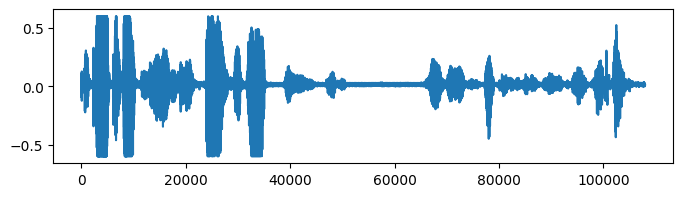

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2))
plt.plot(batch.wav_16k[0].squeeze().detach().cpu().float().numpy())
plt.show()

In [147]:
batch._fields

('x',
 'x_lengths',
 'y',
 'y_lengths',
 'cond',
 'wav_16k',
 'wav_16k_lengths',
 'wav_16k_start_offset',
 'wav_16k_end_offset',
 'texts')

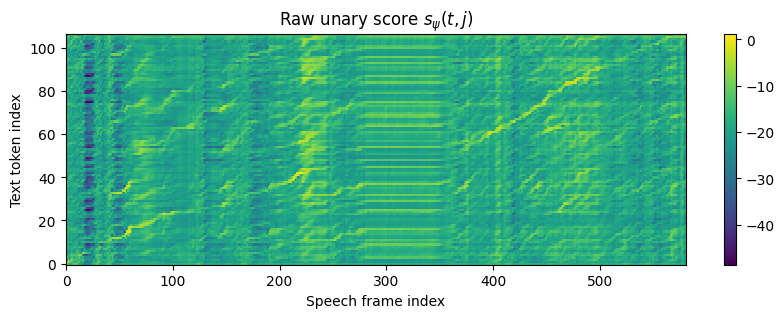

In [148]:
import matplotlib.pyplot as plt

raw_unary = features.raw_unary.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(raw_unary, origin="lower", aspect="auto", interpolation="nearest")
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Raw unary score $s_\psi(t,j)$")
plt.colorbar()
plt.show()

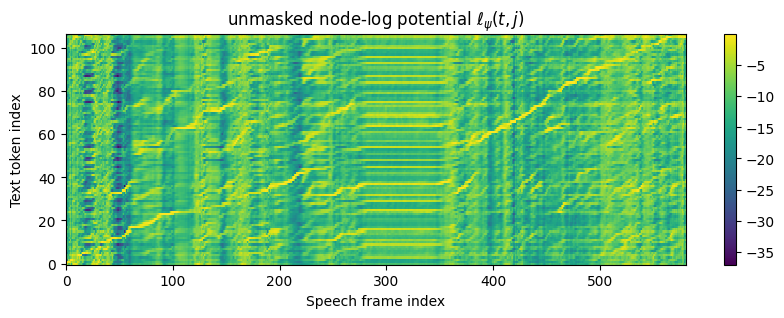

In [149]:
import matplotlib.pyplot as plt

raw_unary = features.log_b.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(raw_unary, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"unmasked node-log potential $\ell_\psi(t,j)$")
plt.show()

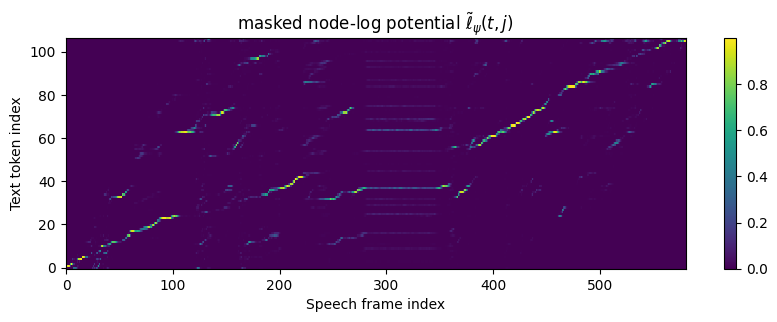

In [150]:
import torch
import matplotlib.pyplot as plt

b = 0
log_b = features.log_b[b]  # (T_s, T_t)

s_len = int(batch.y_lengths[b].item())
t_len = int(batch.x_lengths[b].item())

log_b = log_b[:s_len, :t_len].exp()  # (T_s, T_t)
device = log_b.device

t = torch.arange(s_len, device=device).view(s_len, 1)
j = torch.arange(t_len, device=device).view(1, t_len)

reachable = (j <= t) & ((t_len - 1 - j) <= (s_len - 1 - t))
fill_value = log_b[reachable].min()
masked_log_b = log_b.masked_fill(~reachable, fill_value)
masked_log_b_np = masked_log_b.T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(
    masked_log_b_np,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
)
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"masked node-log potential $\tilde{\ell}_\psi(t,j)$")
plt.show()

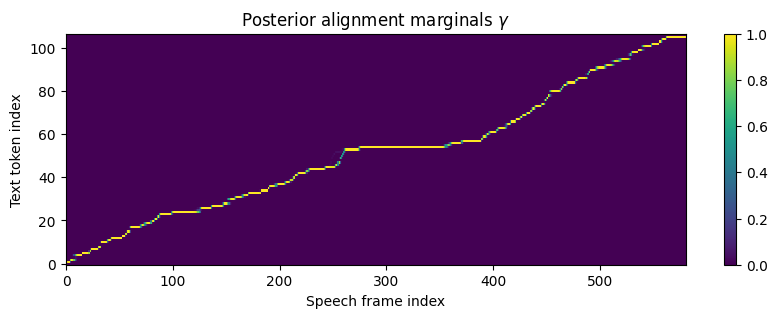

In [151]:
import matplotlib.pyplot as plt

soft_attn = features.soft_attn.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(soft_attn, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Posterior alignment marginals $\gamma$")
plt.show()

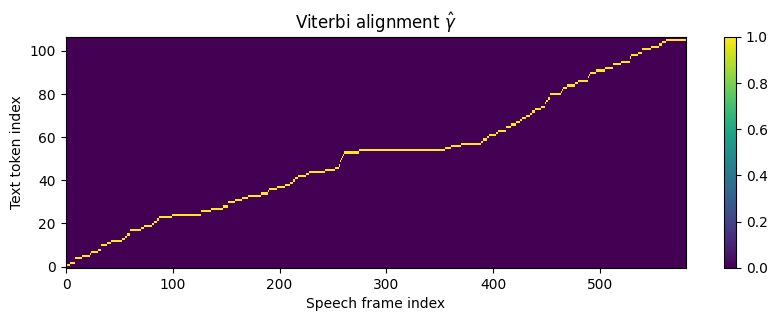

In [152]:
import matplotlib.pyplot as plt

hard_attn = features.hard_attn.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(hard_attn, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Viterbi alignment $\hat{\gamma}$")
plt.show()

In [153]:
wav2_path = "/shared/data_zfs/blue2959/TIMIT/TEST/DR7/FGWR0/SI2208.WAV"
text2 = "Yes, because you didn't run off to use that new toothbrush."

grids = aligner.inference_from_wavs(
    wav_paths=[wav_path, wav2_path],
    texts=[text, text2],
    compute_phone_grid=True,
    compute_word_grid=True,
    include_space_token_to_grid=True,
)

In [154]:
grids.token_ids

tensor([[ 15,  61,  82,  15,  61, 156,  75, 158,  52,  15,  69,  43, 157,  42,
         135,  61,  15,  54, 156,  75, 158, 122,  82,  53,  67,  15, 156, 138,
          54,  15,  64, 101,  80, 157,  42, 135,  61,  15,  43, 122, 156, 101,
         111, 101, 111,  15, 156, 138,  15, 156, 101,  55,  56, 135,  15, 122,
         177,  53, 156, 101,  45, 147,  82,  60,  15,  43, 156,  71,  52,  91,
         122,  42, 135,  55,  45,  15,  75, 158, 122,  15,  60, 156, 138,  54,
         118, 101, 111,  15, 157, 101,  55,  61, 135,  15, 101, 124,  15, 156,
          42, 101,  15, 118, 156, 101, 111,  52,  15],
        [ 15,  51, 156,  85,  60,  15,   2,  15,  43, 101,  52, 156, 138,  67,
          15,  51,  62, 158,  15,  45, 156, 101,  45,  55,  61,  15, 122, 156,
         138,  55,  15, 156,  75,  47,  15,  61,  82,  15,  51, 156,  62, 158,
          67,  15,  80,  71,  61,  15,  55, 156,  62, 158,  15,  61, 156,  62,
         158, 118,  43, 122, 138, 131,  15,   3,  15,   0,   0,   0,   0,   

In [155]:
grids.token_lengths

tensor([107,  65], device='cuda:0')

In [156]:
grids.durations

tensor([[23,  3,  4,  0,  7,  7,  1,  7,  3,  0,  5,  4, 10,  3,  2,  3,  0, 10,
          3,  7,  2,  3,  2, 12, 27,  0, 10, 11,  5,  0,  6,  8,  4, 12,  7,  1,
          7,  8,  5,  2,  2,  3,  8,  2, 15, 10,  3,  1,  0,  1,  1,  1,  1, 14,
         81,  5, 10, 18,  2,  4,  2,  6,  2,  8,  0,  4,  5,  4,  2,  3,  4,  2,
          3,  5,  4,  0,  1,  2,  2,  0, 10,  1,  1,  4,  7,  3,  9,  0,  1,  1,
          6,  8,  8,  0,  7,  9,  0,  1,  6,  4,  0,  8,  8,  3,  3, 19,  3],
        [ 9,  9, 15,  1, 11,  0,  3,  0,  3,  5,  1, 10,  1,  4,  0,  2,  3,  2,
          0,  4,  6,  2,  1,  2,  1,  0, 11,  9,  1,  1,  0, 10,  4,  6,  0,  6,
          2,  0, 11,  2,  7,  2,  7,  0,  4, 12,  2,  0,  7,  2,  8,  1,  0,  9,
          2,  2,  1,  6,  6,  2, 12, 17,  0,  9,  4,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]],
       device='cuda:0')

In [157]:
grids.phones

['tə tˈɔːk ɐbˌaʊt mˈɔːɹəlz ˈʌm wɪðˌaʊt bɹˈɪŋɪŋ ˈʌ ˈɪnoʊ ɹᵻlˈɪdʒəs bˈækɡɹaʊnd ɔːɹ sˈʌmθɪŋ ˌɪntʊ ɪɾ ˈaɪ θˈɪŋk',
 'jˈɛs , bɪkˈʌz juː dˈɪdnt ɹˈʌn ˈɔf tə jˈuːz ðæt nˈuː tˈuːθbɹʌʃ .']

In [158]:
for i in range(2):
    x = aligner.input_maker.tokenizer.decode_to_symbols(grids.token_ids[i, :grids.token_lengths[i]])
    for j in x:
        print(j, end="")
    print()

 tə tˈɔːk ɐbˌaʊt mˈɔːɹəlz ˈʌm wɪðˌaʊt bɹˈɪŋɪŋ ˈʌ ˈɪnoʊ ɹᵻlˈɪdʒəs bˈækɡɹaʊnd ɔːɹ sˈʌmθɪŋ ˌɪntʊ ɪɾ ˈaɪ θˈɪŋk 
 jˈɛs , bɪkˈʌz juː dˈɪdnt ɹˈʌn ˈɔf tə jˈuːz ðæt nˈuː tˈuːθbɹʌʃ . 


In [159]:
from __future__ import annotations

from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


def plot_alignment_with_waveform(
    wav_paths: str | Path | list[str | Path],
    grids,
    sample_idx: int = 0,
    *,
    sr: int | None = None,
    title: str | None = None,
    use_grid_time_range: bool = False,
    margin_sec: float = 0.03,
    figsize: tuple[float, float] = (16, 7),
    waveform_linewidth: float = 0.8,
    boundary_alpha: float = 0.85,
    boundary_linestyle: tuple[int, tuple[int, int]] = (0, (2, 3)),
    word_fontsize: int = 18,
    phone_fontsize: int = 16,
    title_fontsize: int = 22,
    xlabel_fontsize: int = 18,
    space_facecolor: str = "0.85",
    waveform_space_alpha: float = 0.75,
):
    if isinstance(wav_paths, (str, Path)):
        wav_path_list = [wav_paths]
    else:
        wav_path_list = list(wav_paths)

    wav_path = Path(wav_path_list[sample_idx])
    word_grid = grids.word_grid[sample_idx]
    phoneme_grid = grids.phoneme_grid[sample_idx]

    wav, loaded_sr = librosa.load(
        str(wav_path),
        sr=sr,
        mono=True,
    )

    sr_used = loaded_sr
    duration_sec = len(wav) / sr_used
    time_axis = np.arange(len(wav)) / sr_used

    if title is None:
        title = wav_path.stem

    if use_grid_time_range and (
        len(word_grid) > 0
        or len(phoneme_grid) > 0
    ):
        starts = []
        ends = []

        if len(word_grid) > 0:
            starts.append(word_grid[0][0])
            ends.append(word_grid[-1][1])

        if len(phoneme_grid) > 0:
            starts.append(phoneme_grid[0][0])
            ends.append(phoneme_grid[-1][1])

        x_min = max(
            0.0,
            min(starts) - margin_sec,
        )
        x_max = min(
            duration_sec,
            max(ends) + margin_sec,
        )
    else:
        x_min = 0.0
        x_max = duration_sec

    boundary_times: list[float] = []

    for start_sec, end_sec, _ in phoneme_grid:
        boundary_times.append(float(start_sec))
        boundary_times.append(float(end_sec))

    for start_sec, end_sec, _ in word_grid:
        boundary_times.append(float(start_sec))
        boundary_times.append(float(end_sec))

    boundary_times = sorted(set(boundary_times))

    # 공백 구간 수집.
    # word_grid와 phoneme_grid에 동일한 공백이 들어갈 수 있으므로 set으로 중복 제거.
    space_regions = {
        (
            float(start_sec),
            float(end_sec),
        )
        for start_sec, end_sec, label in (
            list(word_grid) + list(phoneme_grid)
        )
        if str(label).strip() == ""
        and float(end_sec) > float(start_sec)
    }

    space_regions = sorted(space_regions)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={
            "height_ratios": [2.2, 1.4, 1.4],
            "hspace": 0.0,
        },
    )

    ax_wav, ax_word, ax_phone = axes

    # ------------------------------------------------------------
    # Waveform
    # ------------------------------------------------------------
    for start_sec, end_sec in space_regions:
        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)

        if vis_end <= vis_start:
            continue

        ax_wav.axvspan(
            vis_start,
            vis_end,
            facecolor=space_facecolor,
            alpha=waveform_space_alpha,
            linewidth=0.0,
            zorder=0,
        )

    ax_wav.plot(
        time_axis,
        wav,
        linewidth=waveform_linewidth,
        zorder=1,
    )
    ax_wav.set_xlim(x_min, x_max)
    ax_wav.set_yticks([])
    # ax_wav.set_title(
    #     title,
    #     fontsize=title_fontsize,
    #     pad=18,
    # )

    # ------------------------------------------------------------
    # Word tier
    # ------------------------------------------------------------
    ax_word.set_ylim(0, 1)
    ax_word.set_yticks([])

    for start_sec, end_sec, label in word_grid:
        start_sec = float(start_sec)
        end_sec = float(end_sec)

        if end_sec < x_min or start_sec > x_max:
            continue

        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)
        width = max(0.0, vis_end - vis_start)

        is_space = str(label).strip() == ""

        rect = Rectangle(
            (vis_start, 0),
            width,
            1,
            facecolor=(
                space_facecolor
                if is_space
                else "none"
            ),
            edgecolor="black",
            linewidth=1.0,
        )
        ax_word.add_patch(rect)

        center = (start_sec + end_sec) / 2.0

        if (
            x_min <= center <= x_max
            and not is_space
        ):
            ax_word.text(
                center,
                0.5,
                str(label),
                ha="center",
                va="center",
                fontsize=word_fontsize,
            )

    # ------------------------------------------------------------
    # Phoneme tier
    # ------------------------------------------------------------
    ax_phone.set_ylim(0, 1)
    ax_phone.set_yticks([])

    for start_sec, end_sec, label in phoneme_grid:
        start_sec = float(start_sec)
        end_sec = float(end_sec)

        if end_sec < x_min or start_sec > x_max:
            continue

        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)
        width = max(0.0, vis_end - vis_start)

        is_space = str(label).strip() == ""

        rect = Rectangle(
            (vis_start, 0),
            width,
            1,
            facecolor=(
                space_facecolor
                if is_space
                else "none"
            ),
            edgecolor="black",
            linewidth=1.0,
        )
        ax_phone.add_patch(rect)

        center = (start_sec + end_sec) / 2.0

        if (
            x_min <= center <= x_max
            and not is_space
        ):
            ax_phone.text(
                center,
                0.5,
                str(label),
                ha="center",
                va="center",
                fontsize=phone_fontsize,
            )

    # ------------------------------------------------------------
    # Alignment boundaries
    # ------------------------------------------------------------
    for t in boundary_times:
        if x_min <= t <= x_max:
            ax_wav.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
                zorder=2,
            )

            ax_word.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
            )

            ax_phone.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
            )

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

    ax_phone.tick_params(
        axis="x",
        labelsize=20,
    )

    ax_phone.set_xlabel(
        "Time (s)",
        fontsize=xlabel_fontsize,
    )

    fig.tight_layout()

    return fig, axes

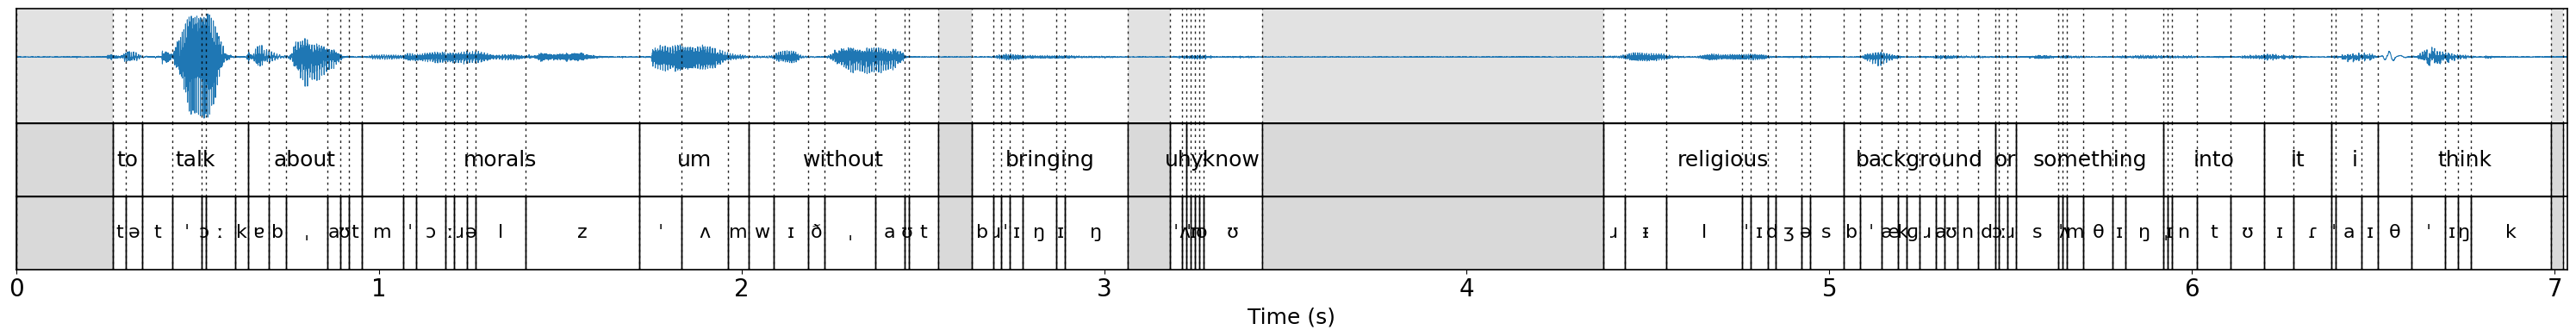

In [160]:
fig, axes = plot_alignment_with_waveform(
    wav_paths=[wav_path, wav2_path],
    grids=grids,
    sample_idx=0,
    use_grid_time_range=False,   # 전체 wav
    figsize=(30, 4)
)

In [161]:
x = grids.word_grid[0]

for ss, es, word in x:
    word = "<sp>" if word == " " else word
    print(f"{word:8s}: {ss * 16000:.2f}, {es * 16000:.2f}")

<sp>    : 0.00, 4272.47
to      : 4272.47, 5572.79
talk    : 5572.79, 10216.78
about   : 10216.78, 15232.29
morals  : 15232.29, 27492.43
um      : 27492.43, 32322.18
without : 32322.18, 40681.36
<sp>    : 40681.36, 42167.44
bringing: 42167.44, 49040.54
<sp>    : 49040.54, 50898.14
uh      : 50898.14, 51641.18
yknow   : 51641.18, 54984.85
<sp>    : 54984.85, 70031.38
religious: 70031.38, 80619.68
background: 80619.68, 87307.03
or      : 87307.03, 88235.83
something: 88235.83, 94737.41
into    : 94737.41, 99195.65
it      : 99195.65, 102167.80
i       : 102167.80, 104211.16
think   : 104211.16, 111827.30
<sp>    : 111827.30, 112384.58
